Discovered thread counts: [1, 2, 4, 8, 16, 32]


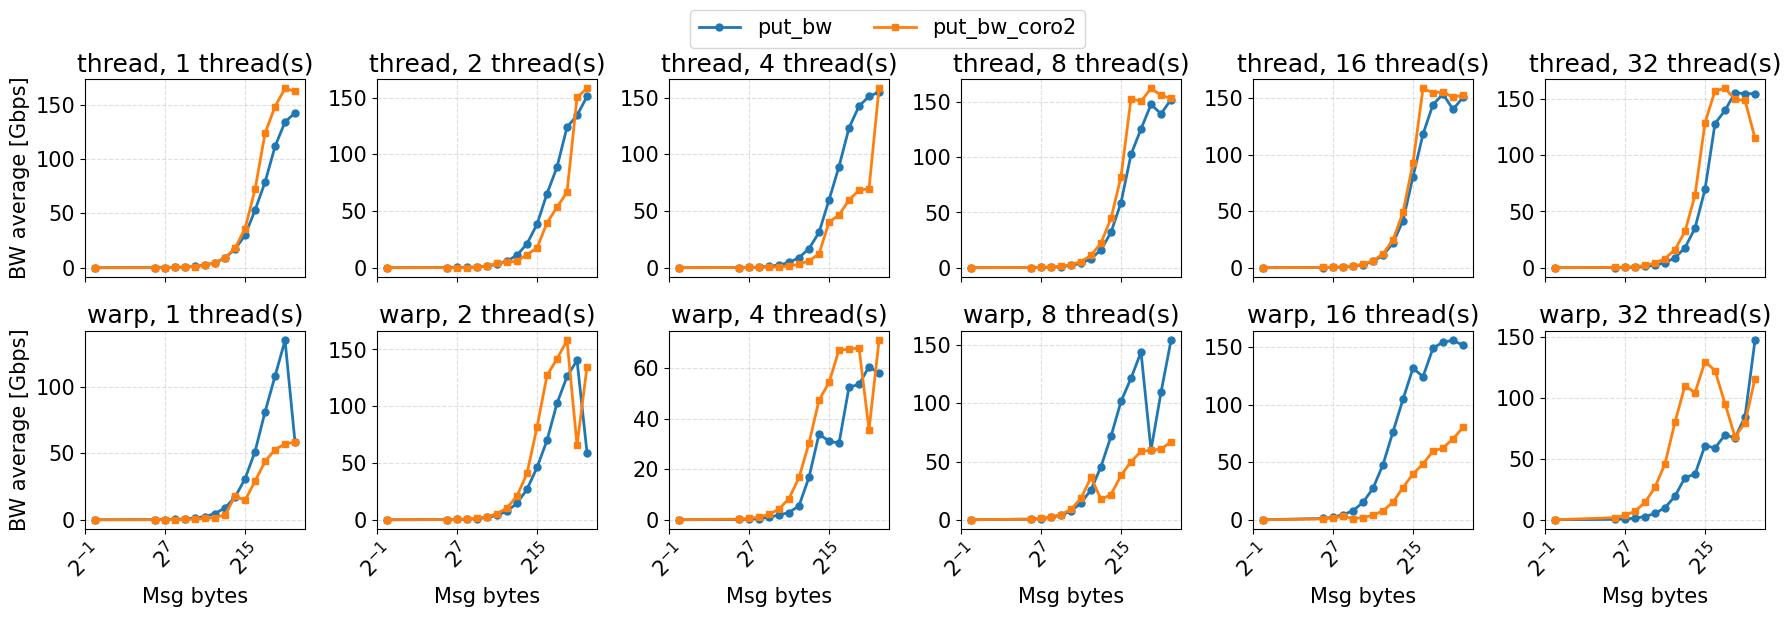

In [12]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 15})


# ===================== 配置区 =====================
BASE_DIR = Path("/home/tyh/gpunetio/test1")

# 三个比较对象，对应路径：
# /home/tyh/gpunetio/test1/put_bw/...
# /home/tyh/gpunetio/test1/put_bw_coro2/...
# /home/tyh/gpunetio/test1/put_bw_coro4/...
OBJECTS = ["put_bw", "put_bw_coro2", "put_bw_coro4"]

# 两种模式，对应路径：
# /home/tyh/gpunetio/test1/put_bw/thread/...
# /home/tyh/gpunetio/test1/put_bw/warp/...
MODES = ["thread", "warp"]

# 日志文件格式：1b1t.log, 1b2t.log, 1b4t.log ...
# 其中 1b 固定，1t / 2t / 4t 表示线程数
LOG_PATTERN = "1b*t.log"

# 是否使用 log2 横坐标
USE_LOG_X = True

# 图片大小
FIG_WIDTH_PER_COL = 3
FIG_HEIGHT_PER_ROW = 3

# =================================================


def parse_log_file(log_path: Path) -> pd.DataFrame:
    """
    解析单个日志文件，提取：
    #bytes, #iterations, BW average[Gbps], MsgRate[Mpps], CUDA Kernel[ms]
    """
    rows = []

    if not log_path.exists():
        return pd.DataFrame(columns=["bytes", "iterations", "bw_gbps", "msg_rate_mpps", "cuda_kernel_ms"])

    line_re = re.compile(
        r"^\s*(\d+)\s+(\d+)\s+([0-9.eE+-]+)\s+([0-9.eE+-]+)\s+([0-9.eE+-]+)"
    )

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = line_re.match(line)
            if m:
                rows.append({
                    "bytes": int(m.group(1)),
                    "iterations": int(m.group(2)),
                    "bw_gbps": float(m.group(3)),
                    "msg_rate_mpps": float(m.group(4)),
                    "cuda_kernel_ms": float(m.group(5)),
                })

    return pd.DataFrame(rows)


def extract_thread_num(log_path: Path):
    """
    从文件名中提取线程数：
    1b1t.log -> 1
    1b2t.log -> 2
    1b16t.log -> 16
    """
    m = re.match(r"1b(\d+)t\.log$", log_path.name)
    if m:
        return int(m.group(1))
    return None


def discover_threads():
    """
    自动发现所有对象、所有模式下存在的线程数。
    """
    thread_nums = set()

    for obj in OBJECTS:
        for mode in MODES:
            log_dir = BASE_DIR / obj / mode
            if not log_dir.exists():
                continue

            for log_path in log_dir.glob(LOG_PATTERN):
                t = extract_thread_num(log_path)
                if t is not None:
                    thread_nums.add(t)

    return sorted(thread_nums)


# 自动发现线程数
THREADS = discover_threads()

if len(THREADS) == 0:
    raise RuntimeError(
        f"没有发现任何日志文件，请检查路径。\n"
        f"当前搜索路径示例：{BASE_DIR}/put_bw/thread/1b1t.log"
    )

print("Discovered thread counts:", THREADS)

# 组织数据：
# data[(mode, thread, obj)] = dataframe
data = {}

for mode in MODES:
    for t in THREADS:
        for obj in OBJECTS:
            log_path = BASE_DIR / obj / mode / f"1b{t}t.log"
            df = parse_log_file(log_path)
            data[(mode, t, obj)] = df

            # if df.empty:
            #     print(f"[WARN] empty or missing: {log_path}")
            # else:
            #     print(f"[OK] {log_path}, rows={len(df)}")


# ===================== 绘图 =====================
n_rows = len(MODES)          # 2: thread / warp
n_cols = len(THREADS)        # m: 线程数变化

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(FIG_WIDTH_PER_COL * n_cols, FIG_HEIGHT_PER_ROW * n_rows),
    squeeze=False,
    sharex=True,
    sharey=False,
)

colors = {
    "put_bw": "tab:blue",
    "put_bw_coro2": "tab:orange",
    "put_bw_coro4": "tab:green",
}

markers = {
    "put_bw": "o",
    "put_bw_coro2": "s",
    "put_bw_coro4": "^",
}

for row_idx, mode in enumerate(MODES):
    for col_idx, t in enumerate(THREADS):
        ax = axes[row_idx][col_idx]

        for obj in OBJECTS:
            df = data.get((mode, t, obj), pd.DataFrame())

            if df.empty:
                continue

            df = df.sort_values("bytes")

            ax.plot(
                df["bytes"],
                df["bw_gbps"],
                marker=markers.get(obj, "o"),
                linewidth=2,
                markersize=5,
                label=obj,
                color=colors.get(obj, None),
            )

        if USE_LOG_X:
            ax.set_xscale("log", base=2)

        ax.grid(True, which="both", linestyle="--", alpha=0.4)

        ax.set_title(f"{mode}, {t} thread(s)")

        if row_idx == n_rows - 1:
            ax.set_xlabel("Msg bytes")

        if col_idx == 0:
            ax.set_ylabel("BW average [Gbps]")

        # 横坐标显示为实际 bytes
        ax.tick_params(axis="x", rotation=45)

        # 如果该子图完全没有数据
        has_any_data = any(
            not data.get((mode, t, obj), pd.DataFrame()).empty
            for obj in OBJECTS
        )
        if not has_any_data:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
                color="red",
            )

# 只放一个全局 legend
handles, labels = axes[0][0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(OBJECTS),
        frameon=True,
        bbox_to_anchor=(0.5, 1.05),
    )


plt.tight_layout()
plt.show()